In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Load dataset

housing = fetch_california_housing()
# Create DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target # Add target column

#first look
print('shape:', df.shape)
print(df.head())


shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [3]:
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [6]:
print("missing value per column:")
print(df.isnull().sum())

print("toptal missing vlaues")
print(df.isnull().sum().sum())

missing value per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
toptal missing vlaues
0


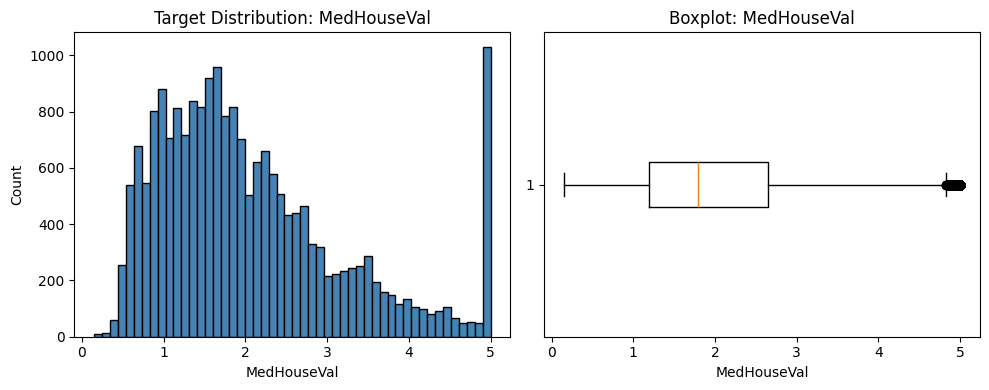

In [4]:
plt.figure(figsize=(10, 4))

#Left Histogram
plt.subplot(1, 2, 1)
plt.hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='black')
plt.title("Target Distribution: MedHouseVal")
plt.xlabel("MedHouseVal")
plt.ylabel("Count")

#Right Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(df['MedHouseVal'], vert=False)
plt.title("Boxplot: MedHouseVal")
plt.xlabel("MedHouseVal")
plt.tight_layout()
plt.show()

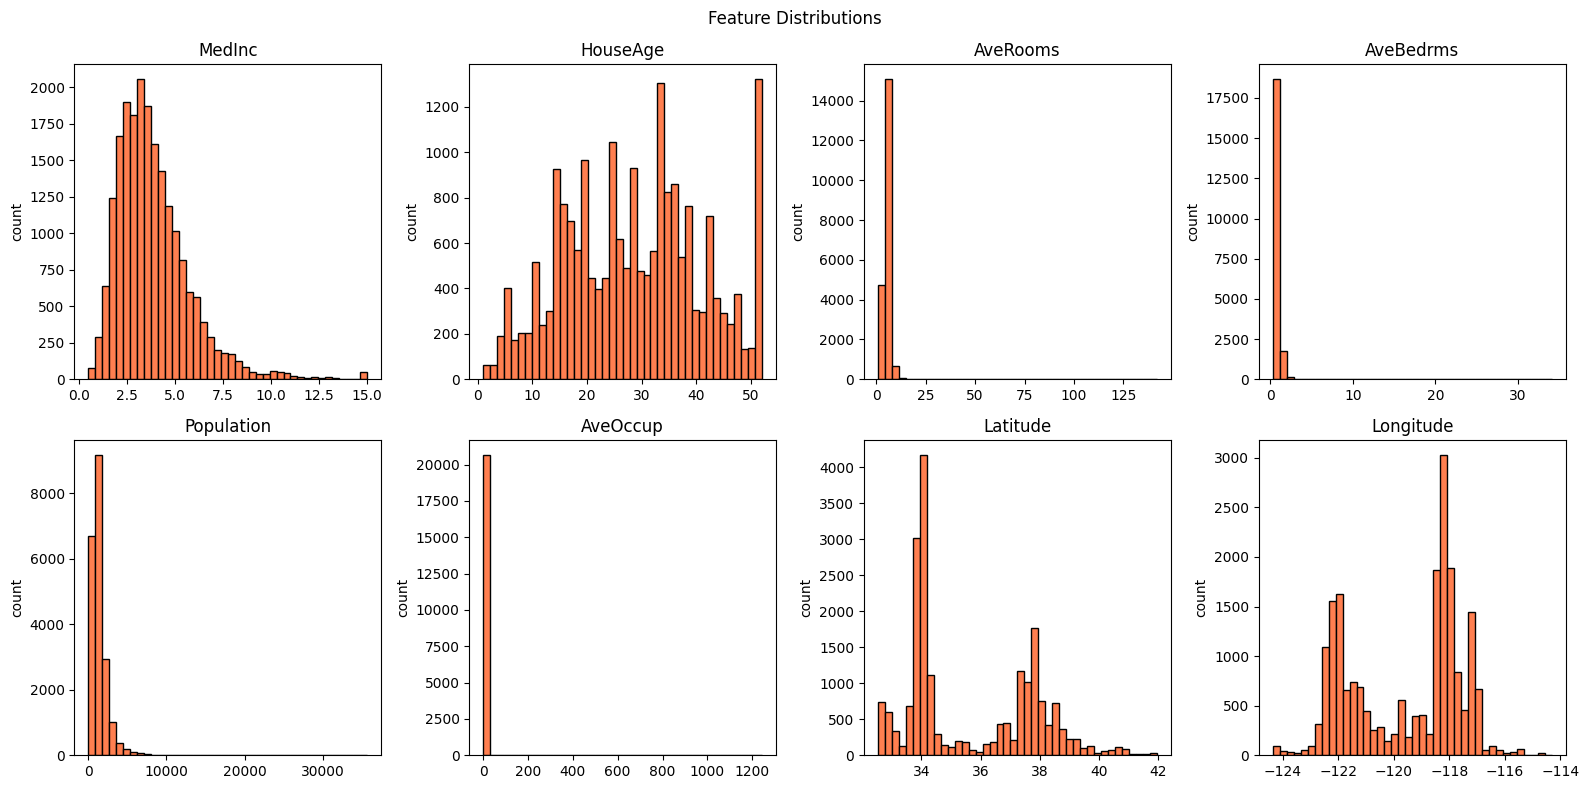

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
features = housing.feature_names
for i, feature in enumerate(features):
    ax = axes[i // 4, i % 4]
    ax.hist(df[feature], bins=40, color='coral', edgecolor='black')
    ax.set_title(feature)
    ax.set_ylabel('count')

plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()    

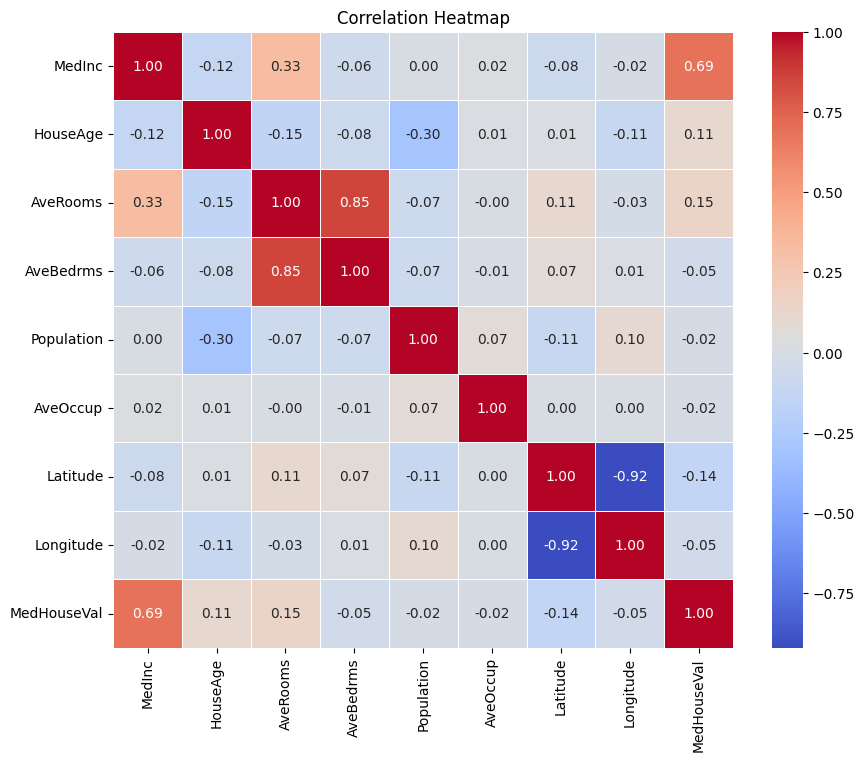

In [9]:
plt.figure(figsize=(10, 8))
corr = df.corr().round(2)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

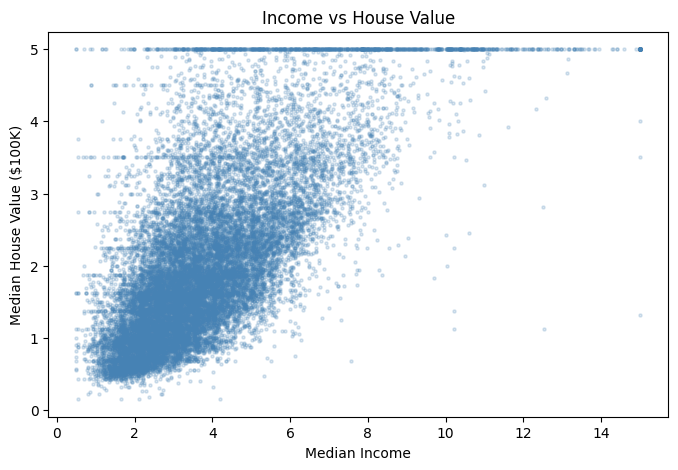

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.2, color='steelblue', s=5)
plt.xlabel('Median Income')
plt.ylabel('Median House Value ($100K)')
plt.title('Income vs House Value')
plt.show()

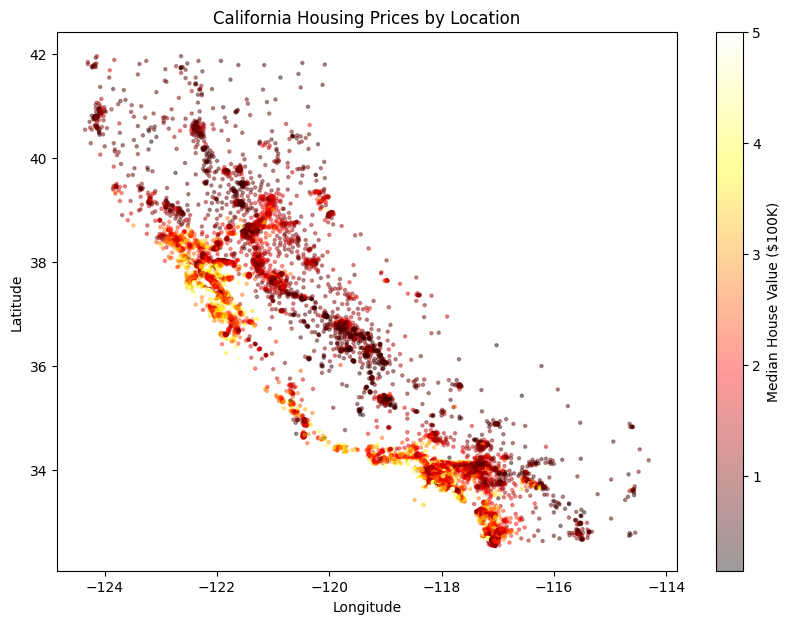

In [11]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df['Longitude'], df['Latitude'],
    c=df['MedHouseVal'], cmap='hot',
    alpha=0.4, s=5
)
plt.colorbar(scatter, label='Median House Value ($100K)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices by Location')
plt.show()

In [12]:
cols_to_check = ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']

for col in cols_to_check:
    print(f"Outliers in {col}:")
    print(f"max: {df[col].max():.2f}")
    print(f"99th percentile: {df[col].quantile(0.99):.2f}")
    print()

Outliers in AveRooms:
max: 141.91
99th percentile: 10.36

Outliers in AveBedrms:
max: 34.07
99th percentile: 2.13

Outliers in AveOccup:
max: 1243.33
99th percentile: 5.39

Outliers in Population:
max: 35682.00
99th percentile: 5805.83



In [14]:
cols_to_cap = ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']

for col in cols_to_cap:
    cap_value = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap_value)
    print(f"{col} capped at {cap_value:.2f}")

AveRooms capped at 10.36
AveBedrms capped at 2.13
AveOccup capped at 5.39
Population capped at 5805.12


In [17]:
X = df.drop("MedHouseVal", axis=1)
Y = df["MedHouseVal"]

print(X.shape)
print(Y.shape)
print(list(X.columns)   )

(20640, 8)
(20640,)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(X_train.shape, Y_train.shape)

(16512, 8) (16512,)


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on TRAIN only, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # NO fit here — only transform

print("Mean of scaled X_train (should be ~0):", X_train_scaled.mean().round(4))
print("Std of scaled X_train (should be ~1):",  X_train_scaled.std().round(4))

Mean of scaled X_train (should be ~0): 0.0
Std of scaled X_train (should be ~1): 1.0


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


In [37]:
##Linear Regression

lr = LinearRegression()
lr.fit(X_train_scaled, Y_train)
lr_pred = lr.predict(X_test_scaled)

lr_mae = mean_absolute_error(Y_test, lr_pred)
lr_rsme = np.sqrt(mean_squared_error(Y_test, lr_pred))
lr_r2 = r2_score(Y_test, lr_pred)

print(f"{lr_mae:.4f}")
print(f"{lr_rsme:.4f}")
print(f"{lr_r2:.4f}")   

0.4978
0.6794
0.6477


In [38]:
##Random Forest Regressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, Y_train)
rf_pred = rf.predict(X_test_scaled)

rf_mae = mean_absolute_error(Y_test, rf_pred)
rf_rsme = np.sqrt(mean_squared_error(Y_test, rf_pred))
rf_r2 = r2_score(Y_test, rf_pred)

print(f"{rf_mae:.4f}")
print(f"{rf_rsme:.4f}")
print(f"{rf_r2:.4f}")

0.3280
0.5055
0.8050


In [40]:
#Decision Tree Regressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, Y_train)
dt_pred = dt.predict(X_test_scaled)

dt_mae  = mean_absolute_error(Y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(Y_test, dt_pred))
dt_r2   = r2_score(Y_test, dt_pred)

print(f"MAE  : {dt_mae:.4f}")
print(f"RMSE : {dt_rmse:.4f}")
print(f"R²   : {dt_r2:.4f}")

MAE  : 0.4552
RMSE : 0.7065
R²   : 0.6191


In [41]:
# Gradient Boosting Regressor

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, Y_train)
gb_pred = gb.predict(X_test_scaled)

gb_mae  = mean_absolute_error(Y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(Y_test, gb_pred))
gb_r2   = r2_score(Y_test, gb_pred)

print("=== Gradient Boosting ===")
print(f"MAE  : {gb_mae:.4f}")
print(f"RMSE : {gb_rmse:.4f}")
print(f"R²   : {gb_r2:.4f}")

=== Gradient Boosting ===
MAE  : 0.3687
RMSE : 0.5382
R²   : 0.7790


In [42]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 
              'Random Forest', 'Gradient Boosting'],
    'MAE':  [lr_mae,  dt_mae,  rf_mae,  gb_mae],
    'RMSE': [lr_rsme, dt_rmse, rf_rsme, gb_rmse],
    'R²':   [lr_r2,   dt_r2,   rf_r2,   gb_r2]
})

results = results.sort_values('R²', ascending=False).reset_index(drop=True)
results[['MAE','RMSE','R²']] = results[['MAE','RMSE','R²']].round(4)

print(results.to_string(index=False))

            Model    MAE   RMSE     R²
    Random Forest 0.3280 0.5055 0.8050
Gradient Boosting 0.3687 0.5382 0.7790
Linear Regression 0.4978 0.6794 0.6477
    Decision Tree 0.4552 0.7065 0.6191
